In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
data  main.ipynb  model  preprocessing	README.md  seg_preparation.ipynb


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# import torch
# from model.autoencoder import Conv3DAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [160, 176, 208] # list(mri_image_1.shape)

# # Initialize model and move it to the correct device
# autoencoder = Conv3DAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [3]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

In [4]:
def brain_crop(brain_data, desired_shape=[160, 176, 208]):
    # Define target shape (160,160,192)
    target_shape = np.array(desired_shape)

    # Compute new crop boundaries
    # start = center - (target_shape // 2)
    start = [48, 36, 8]
    end = start + target_shape

    # Ensure boundaries don't go out of bounds
    end = np.minimum(end, brain_data.shape)

    # Apply cropping
    cropped_data = brain_data[start[0]:end[0], start[1]:end[1], start[2]:end[2]]    
    return cropped_data

(176, 208, 160) 1.0 0.0


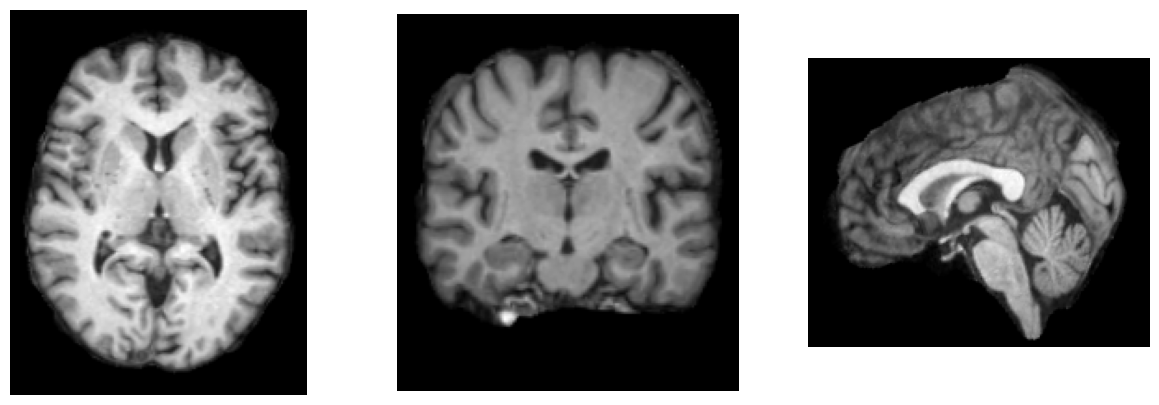

In [5]:
# Load NIfTI file
nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
mri_data = np.flip(nifti_img.get_fdata().transpose((1, 2, 0)), 1)

# Show a single slice (assuming 3D MRI data)
print(mri_data.shape, np.max(mri_data), np.min(mri_data))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()


(176, 208, 160) 255 0 uint8


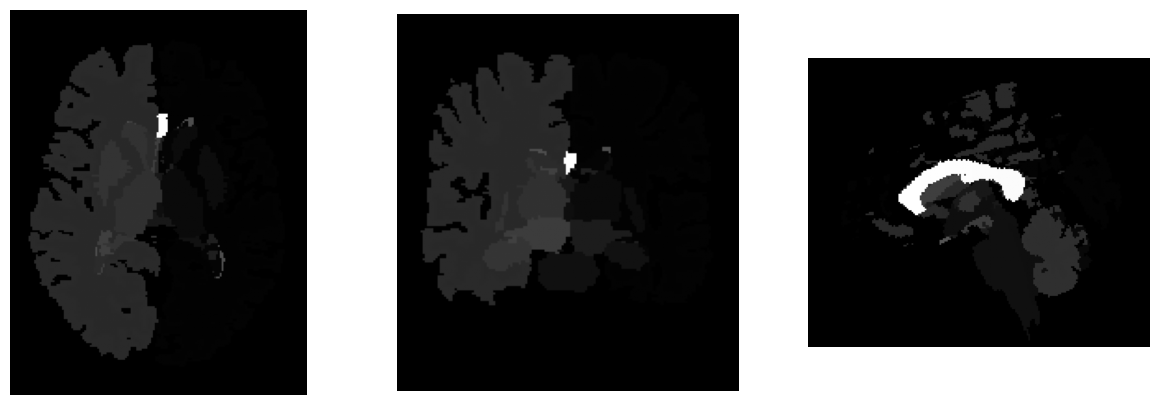

In [6]:
# Load NIfTI file
nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_aseg.nii.gz")
mri_data = nifti_img.get_fdata() 
mri_data = brain_crop(mri_data, desired_shape=[160, 176, 208])
mri_data = np.flip(mri_data.transpose((1, 2, 0)), 1).astype(np.uint8)

# Show a single slice (assuming 3D MRI data)
print(mri_data.shape, np.max(mri_data), np.min(mri_data), mri_data.dtype)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()


In [7]:
# Hippocampus (lh): 17
# Hippocampus (rh): 53
# Amygdala (lh): 18
# Amygdala (rh): 54
# Thalamus (lh): 10
# Thalamus (rh): 49
# Caudate (lh): 11
# Caudate (rh): 50
# Putamen (lh): 12
# Putamen (rh): 51

In [8]:
import os
import numpy as np
import nibabel as nib
from tqdm import tqdm

def convert_nii_to_npy(image_paths, seg_paths, image_ids, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for img_path, seg_path, img_id in tqdm(zip(image_paths, seg_paths, image_ids), total=len(image_paths), desc="Converting to .npy"):
        try:
            # Load and preprocess image
            image = np.array(nib.load(img_path).get_fdata(), dtype=np.float32)
            image = np.flip(image.transpose((1, 2, 0)), 1)
            image = (image * 255).clip(0, 255).astype(np.uint8)

            # Load and preprocess segmentation
            seg = np.array(nib.load(seg_path).get_fdata(), dtype=np.float32)
            seg = brain_crop(seg, desired_shape=[160, 176, 208])
            seg = np.flip(seg.transpose((1, 2, 0)), 1).astype(np.uint8)

            # Save both in a dictionary
            image_seg = {
                "image": image,
                "seg": seg
            }

            # Optional: print for debugging
            # print(f"[{img_id}] image: {image.shape}, seg: {seg.shape}, dtype: {seg.dtype}")

            # Save to .npy file
            # np.save(os.path.join(output_dir, f"{img_id}.npy"), image_seg)

        except Exception as e:
            print(f"❌ Failed to process {img_path}: {e}")


In [9]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_UINT/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')

# Some recordings might be removed, i.e. nan labels
raw_labels = np.array([get_label(image_id, labels_df) for image_id in raw_image_ids]).astype('float32')
raw_ages = np.array([get_label(image_id, labels_df, column='age_at_visit') for image_id in raw_image_ids]).astype('float32')
raw_ids = np.array([get_label(image_id, labels_df, column='OASISID') for image_id in raw_image_ids])

# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages = raw_ages[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2681,) (2680,)


In [10]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths, labels, ages, ids, test_size=0.4, val_size=0.4)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 680 - IR: 0.23
Validation samples: 690 - IR: 0.18
Testing samples: 1310 - IR: 0.39


In [11]:
from preprocessing.load_dataset import StratifiedBatchSampler
import torchio as tio

minibatch_size = 10  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])

# Preparing the dataset to feed the network
train_dataset = BrainMRIDataset(train_set['image_paths'], train_set['ages'], train_set['labels'], 
                                transform=None, transform_age=3, cache=True, return_seg=True)
# train_sampler = StratifiedBatchSampler(train_dataset, minibatch_size)
# train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

# val_dataset = BrainMRIDataset(val_set['image_paths'], val_set['ages'], val_set['labels'], cache=True)
# val_sampler = StratifiedBatchSampler(val_dataset, 2)
# val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

# test_dataset = BrainMRIDataset(test_set['image_paths'], test_set['ages'], test_set['labels'], cache=True)
# test_sampler = StratifiedBatchSampler(test_dataset, 2)
# test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)

Loading 680/680 100.0% ...


In [12]:
dementia_subcortical_indices = {
    "Hippocampus (lh)": 17,
    "Hippocampus (rh)": 53,
    "Amygdala (lh)": 18,
    "Amygdala (rh)": 54,
    "Thalamus (lh)": 10,
    "Thalamus (rh)": 49,
    "Caudate (lh)": 11,
    "Caudate (rh)": 50,
    "Putamen (lh)": 12,
    "Putamen (rh)": 51,
}

Loading Hippocampus (lh) 680/680 100.0% ...
Processing Hippocampus (lh) to extract and plot bounding box...


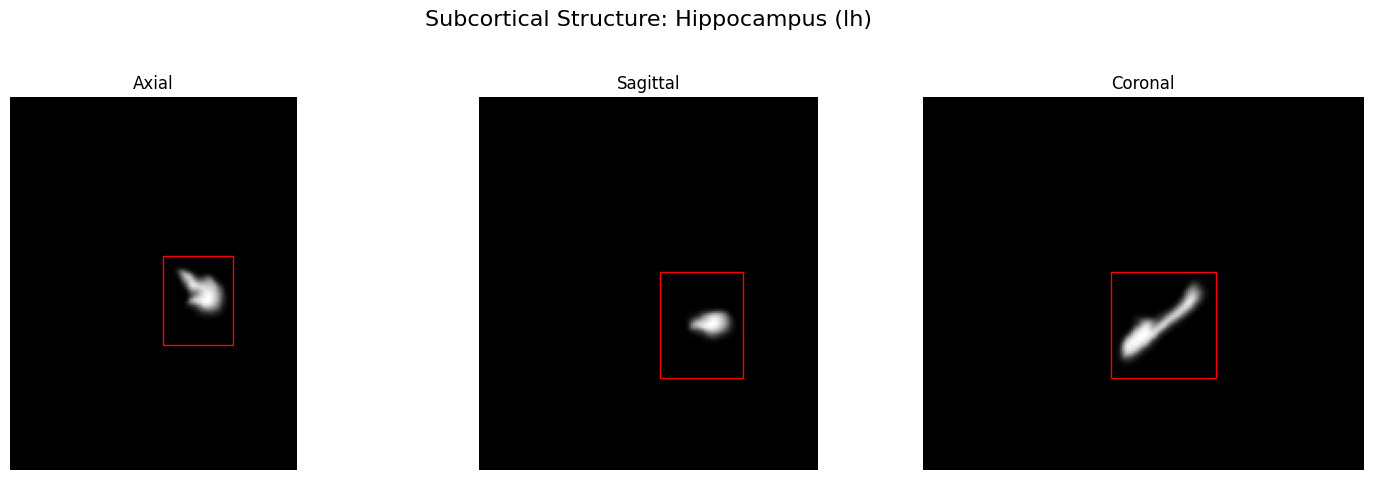

Loading Hippocampus (rh) 680/680 100.0% ...
Processing Hippocampus (rh) to extract and plot bounding box...


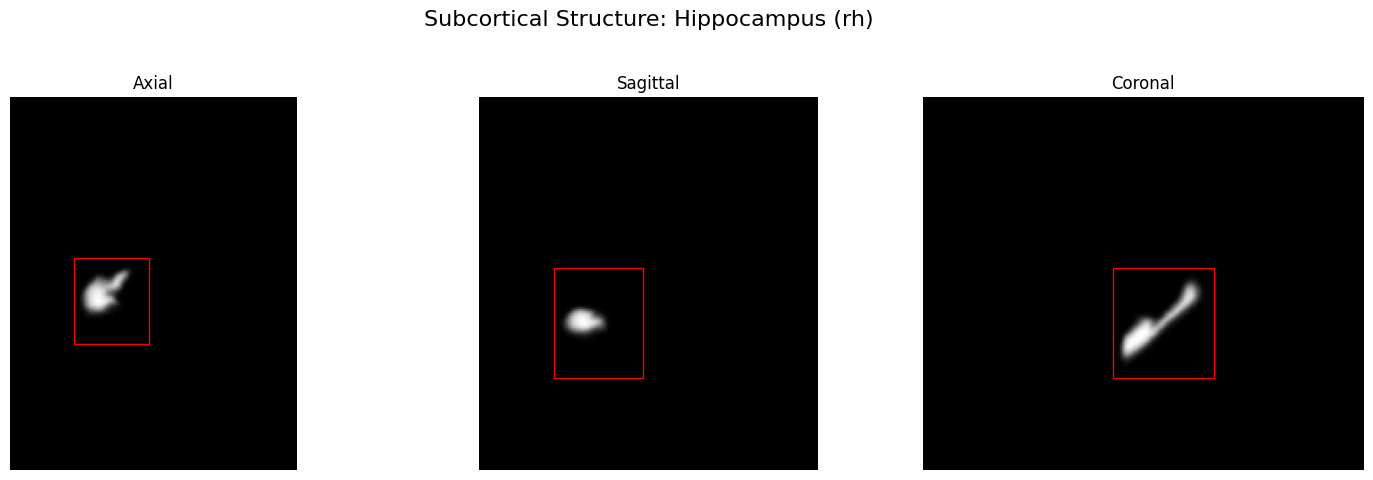

Loading Amygdala (lh) 680/680 100.0% ...
Processing Amygdala (lh) to extract and plot bounding box...


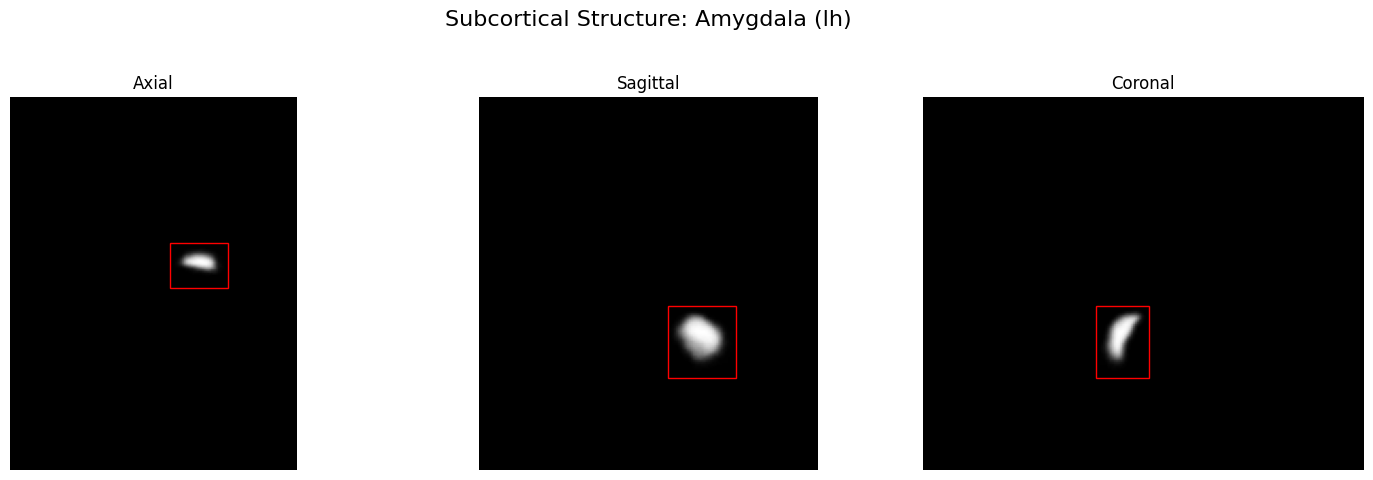

Loading Amygdala (rh) 680/680 100.0% ...
Processing Amygdala (rh) to extract and plot bounding box...


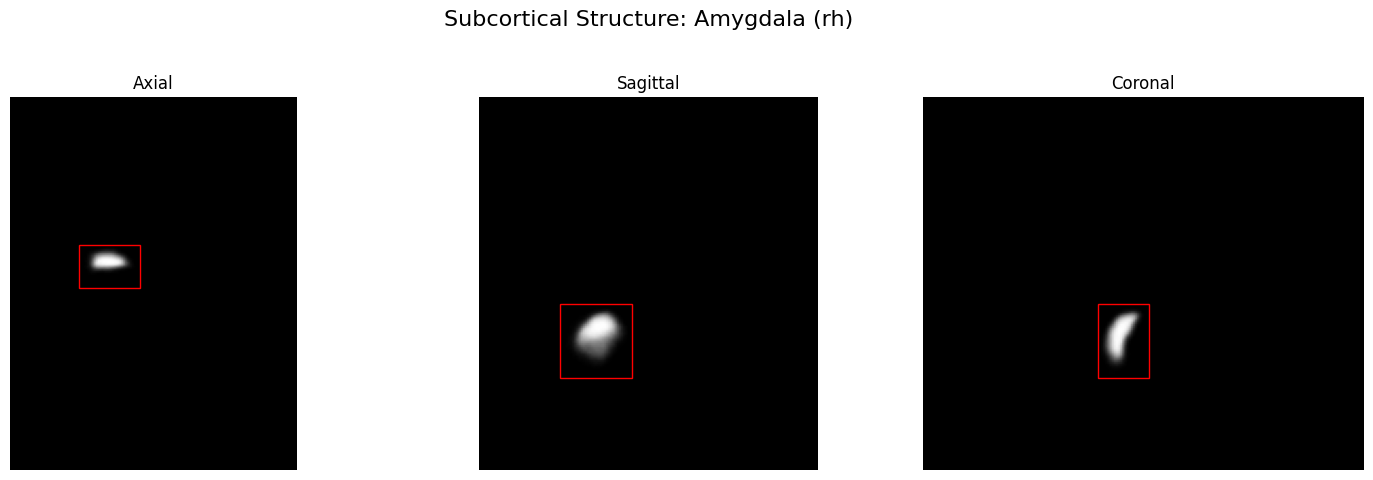

Loading Thalamus (lh) 680/680 100.0% ...
Processing Thalamus (lh) to extract and plot bounding box...


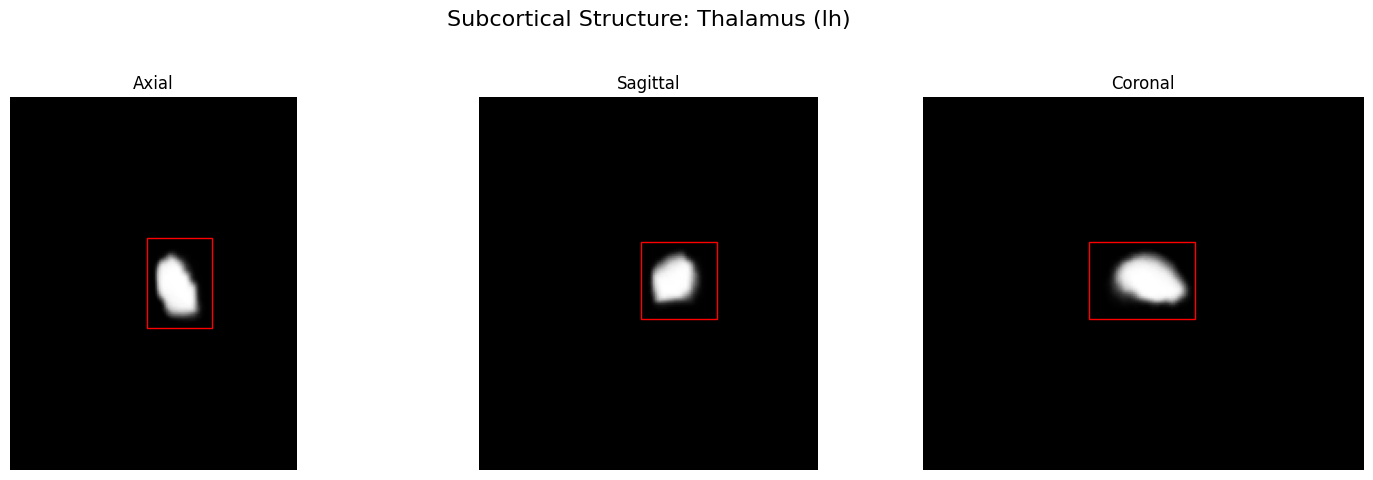

Loading Thalamus (rh) 680/680 100.0% ...
Processing Thalamus (rh) to extract and plot bounding box...


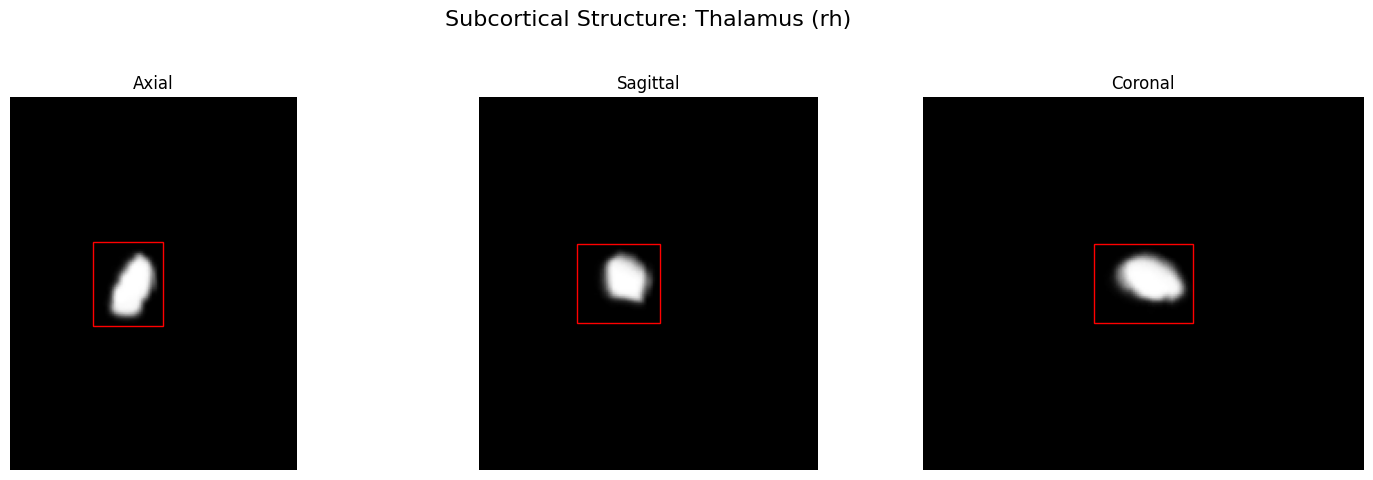

Loading Caudate (lh) 680/680 100.0% ...
Processing Caudate (lh) to extract and plot bounding box...


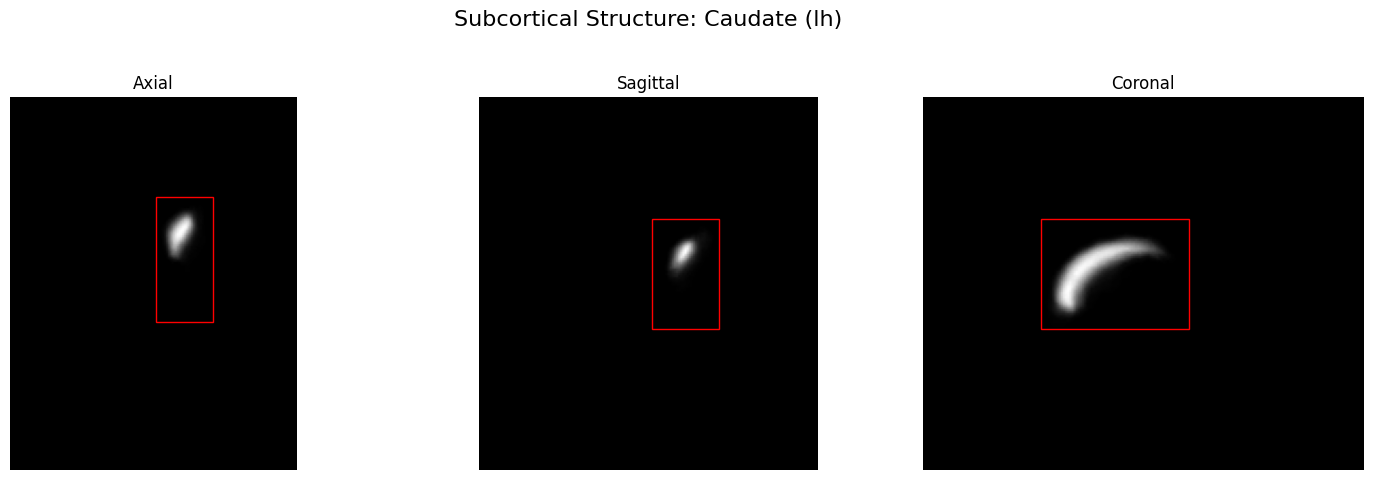

Loading Caudate (rh) 680/680 100.0% ...
Processing Caudate (rh) to extract and plot bounding box...


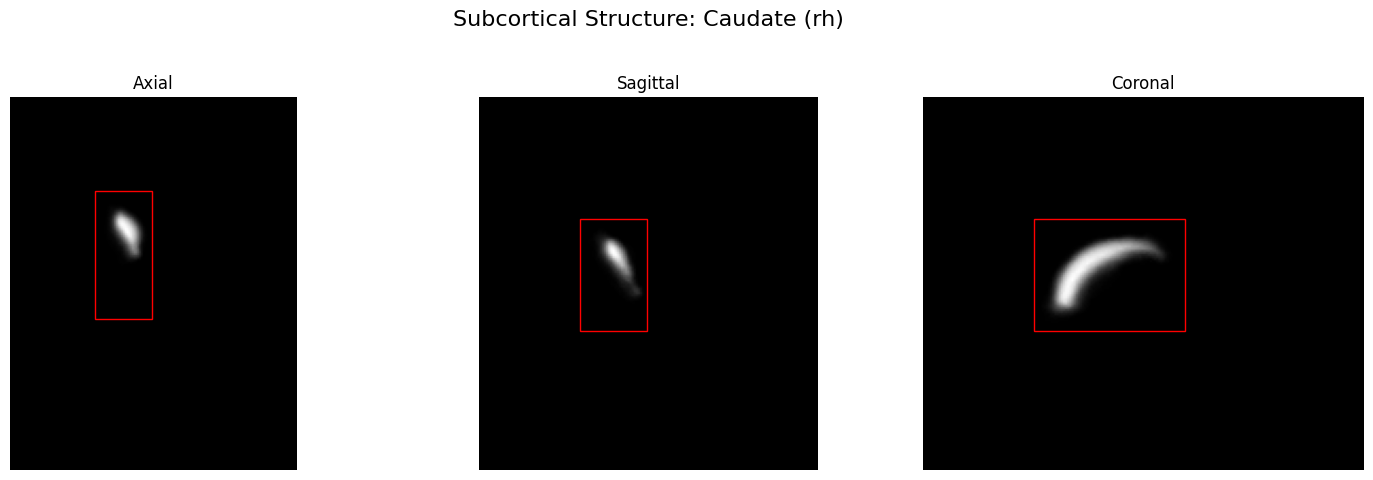

Loading Putamen (lh) 680/680 100.0% ...
Processing Putamen (lh) to extract and plot bounding box...


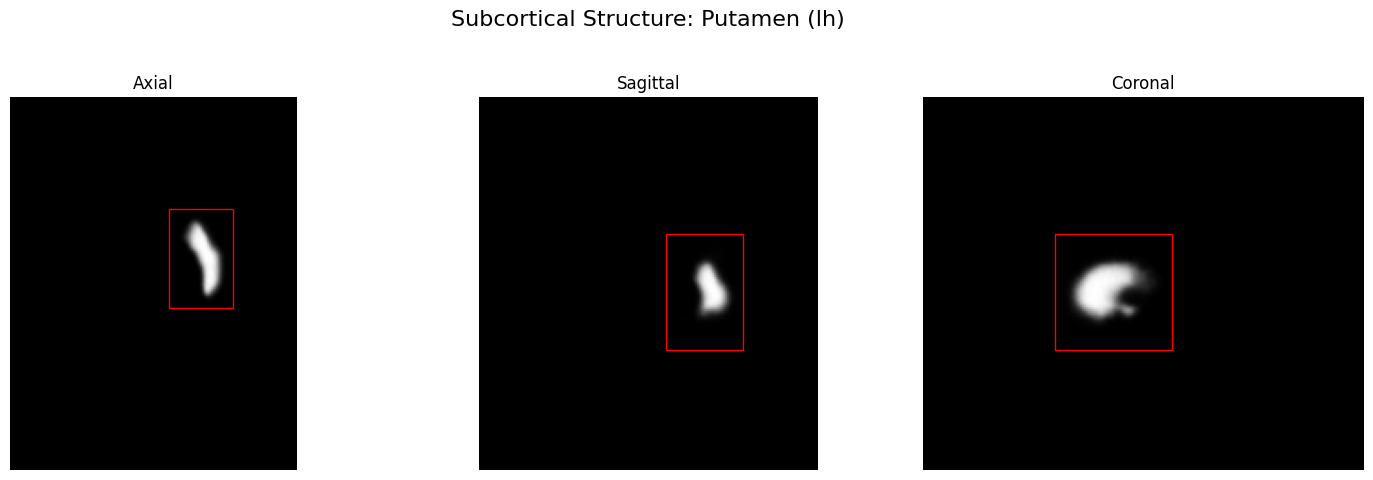

Loading Putamen (rh) 680/680 100.0% ...
Processing Putamen (rh) to extract and plot bounding box...


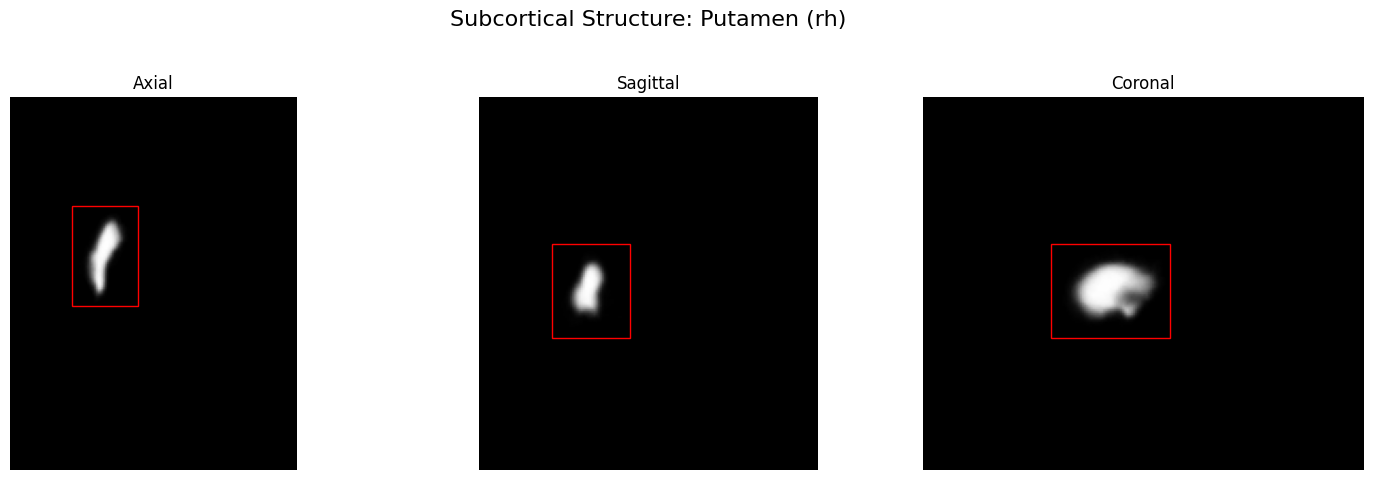


Extracted Bounding Boxes (Coordinates):
Hippocampus (lh): ((82, 88, 85), (132, 138, 124))
Hippocampus (rh): ((80, 89, 35), (132, 137, 77))
Amygdala (lh): ((98, 81, 89), (132, 106, 121))
Amygdala (rh): ((97, 82, 38), (132, 106, 72))
Thalamus (lh): ((68, 78, 76), (104, 128, 112))
Thalamus (rh): ((69, 80, 46), (106, 127, 85))
Caudate (lh): ((57, 55, 81), (109, 125, 113))
Caudate (rh): ((57, 52, 47), (110, 123, 79))
Putamen (lh): ((64, 62, 88), (119, 117, 124))
Putamen (rh): ((69, 60, 34), (113, 116, 71))


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchio as tio

def extract_bounding_box(segmentation_mask):
    nonzero_indices = np.where(segmentation_mask != 0)
    if nonzero_indices[0].size == 0:
        return None
    min_coords = (np.min(nonzero_indices[0]), np.min(nonzero_indices[1]), np.min(nonzero_indices[2]))
    max_coords = (np.max(nonzero_indices[0]), np.max(nonzero_indices[1]), np.max(nonzero_indices[2]))
    return min_coords, max_coords

bounding_boxes = {}

for key, value in dementia_subcortical_indices.items():
    # Initialize an empty segmentation mask for the current structure
    combined_seg = np.zeros_like(train_dataset[0]['seg'].squeeze().cpu().numpy(), dtype=np.uint16)

    # Iterate through the dataset and accumulate the segmentation for the current structure
    for i in range(len(train_dataset)):
        print(f"Loading {key} {i+1}/{len(train_dataset)} {(i+1)/len(train_dataset)*100:.1f}% ...", end='\r')
        segmentation_mask = (train_dataset[i]['seg'].squeeze().cpu().numpy() == value).astype(np.uint16)
        combined_seg += segmentation_mask

    print(f"\nProcessing {key} to extract and plot bounding box...")
    bounding_box = extract_bounding_box(combined_seg)
    bounding_boxes[key] = bounding_box

    if bounding_box:
        min_z, min_y, min_x = bounding_box[0]
        max_z, max_y, max_x = bounding_box[1]

        # Get the middle slices for plotting (within the bounding box)
        mid_z = (min_z + max_z) // 2
        mid_y = (min_y + max_y) // 2
        mid_x = (min_x + max_x) // 2

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"Subcortical Structure: {key}", fontsize=16)

        # Plot axial view
        axes[0].imshow(combined_seg[mid_z, :, :], cmap="gray")
        axes[0].set_title("Axial")
        axes[0].axis("off")
        rect_xy = (min_x, min_y)
        rect_width = max_x - min_x
        rect_height = max_y - min_y
        rect = plt.Rectangle(rect_xy, rect_width, rect_height, linewidth=1, edgecolor='r', facecolor='none')
        axes[0].add_patch(rect)

        # Plot sagittal view
        axes[1].imshow(combined_seg[:, mid_y, :], cmap="gray")
        axes[1].set_title("Sagittal")
        axes[1].axis("off")
        rect_xy = (min_x, min_z)
        rect_width = max_x - min_x
        rect_height = max_z - min_z
        rect = plt.Rectangle(rect_xy, rect_width, rect_height, linewidth=1, edgecolor='r', facecolor='none')
        axes[1].add_patch(rect)

        # Plot coronal view
        axes[2].imshow(combined_seg[:, :, mid_x], cmap="gray")
        axes[2].set_title("Coronal")
        axes[2].axis("off")
        rect_xy = (min_y, min_z)
        rect_width = max_y - min_y
        rect_height = max_z - min_z
        rect = plt.Rectangle(rect_xy, rect_width, rect_height, linewidth=1, edgecolor='r', facecolor='none')
        axes[2].add_patch(rect)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.show()
    else:
        print(f"{key}: No segmentation found across the dataset.")

print("\nExtracted Bounding Boxes (Coordinates):")
for key, bbox in bounding_boxes.items():
    print(f"{key}: {bbox}")

Loading Hippocampus (lh) 680/680 100.0% ...
Processing Hippocampus (lh) to extract bounding box...
Loading Hippocampus (rh) 680/680 100.0% ...
Processing Hippocampus (rh) to extract bounding box...
Loading Amygdala (lh) 680/680 100.0% ...
Processing Amygdala (lh) to extract bounding box...
Loading Amygdala (rh) 680/680 100.0% ...
Processing Amygdala (rh) to extract bounding box...
Loading Thalamus (lh) 680/680 100.0% ...
Processing Thalamus (lh) to extract bounding box...
Loading Thalamus (rh) 680/680 100.0% ...
Processing Thalamus (rh) to extract bounding box...
Loading Caudate (lh) 680/680 100.0% ...
Processing Caudate (lh) to extract bounding box...
Loading Caudate (rh) 680/680 100.0% ...
Processing Caudate (rh) to extract bounding box...
Loading Putamen (lh) 680/680 100.0% ...
Processing Putamen (lh) to extract bounding box...
Loading Putamen (rh) 680/680 100.0% ...
Processing Putamen (rh) to extract bounding box...

Extracted Bounding Boxes (Initial):
Hippocampus (lh): ((82, 88, 8

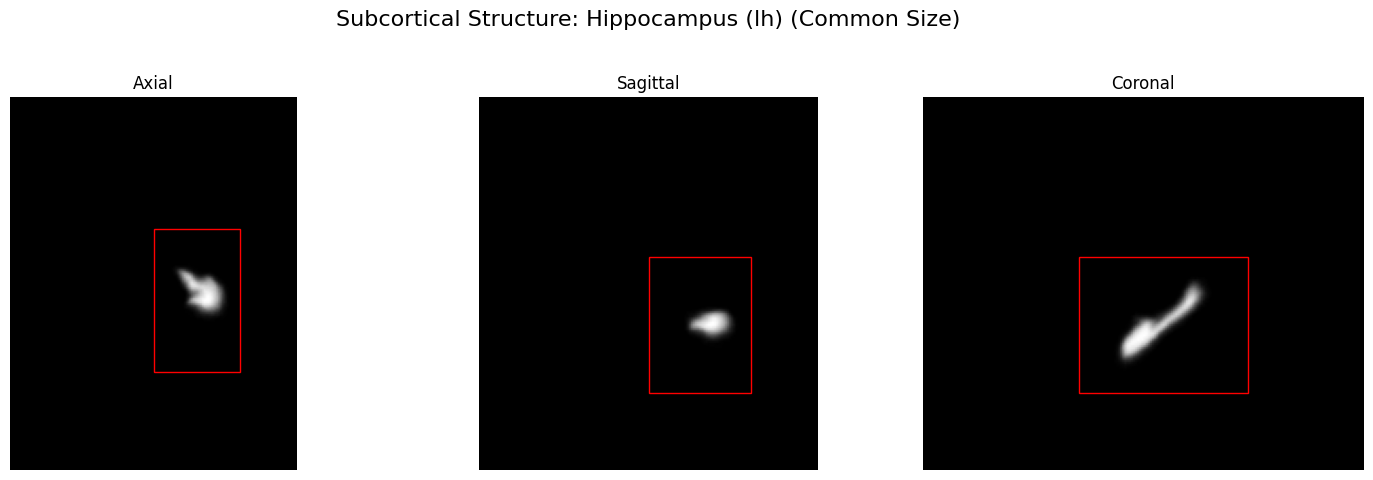

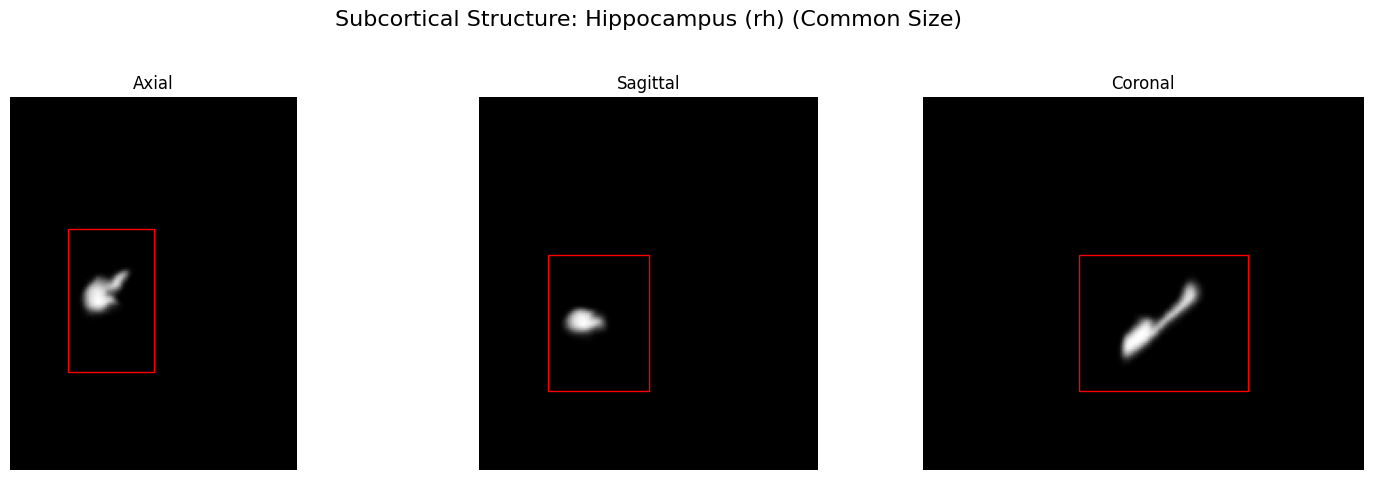

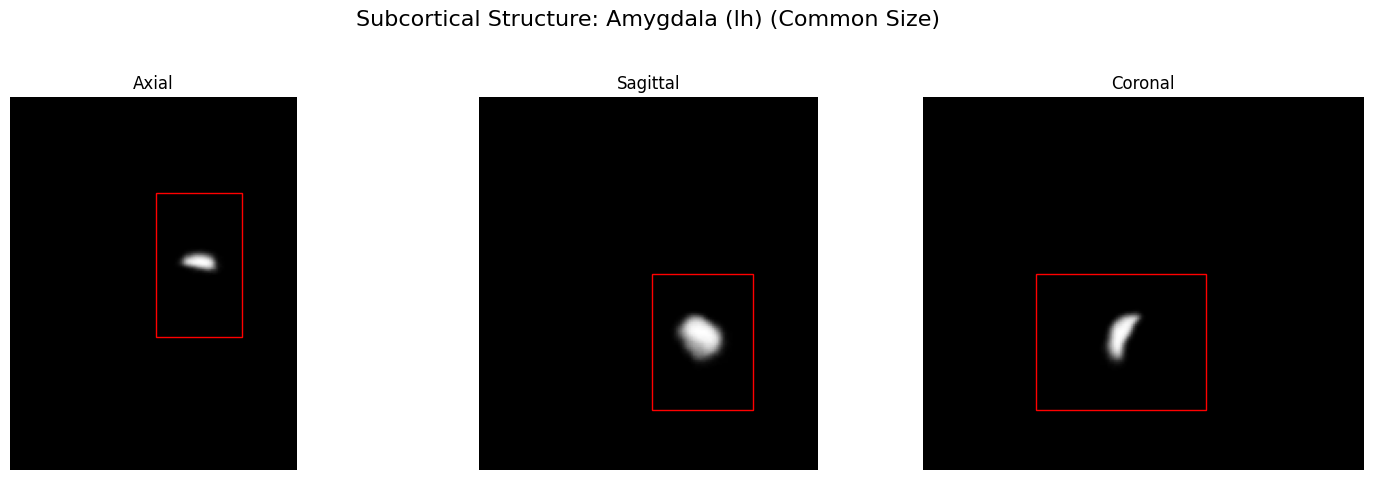

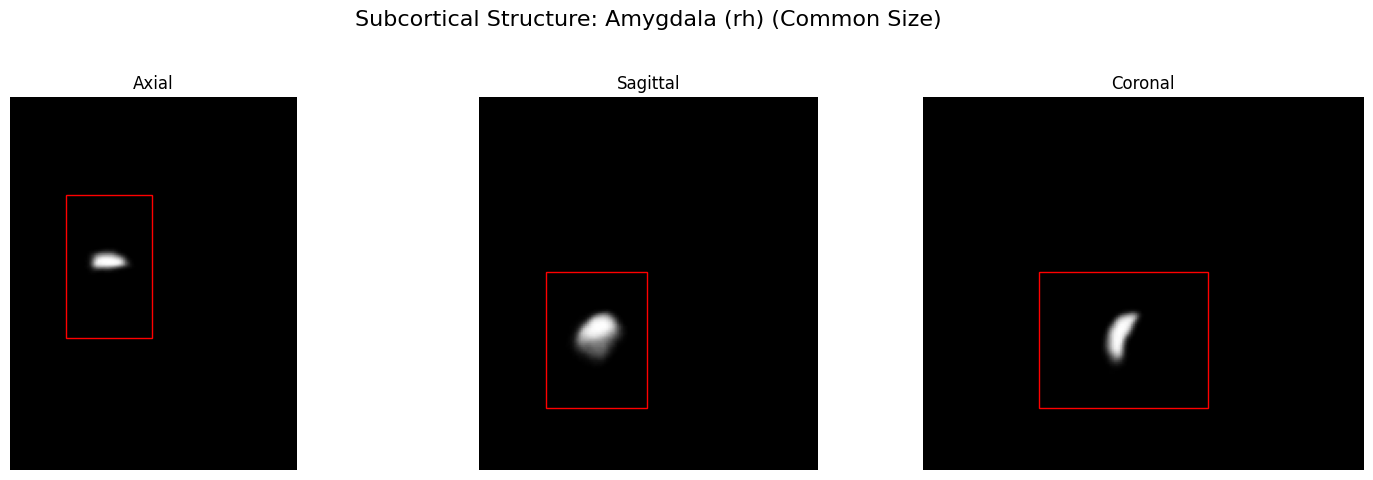

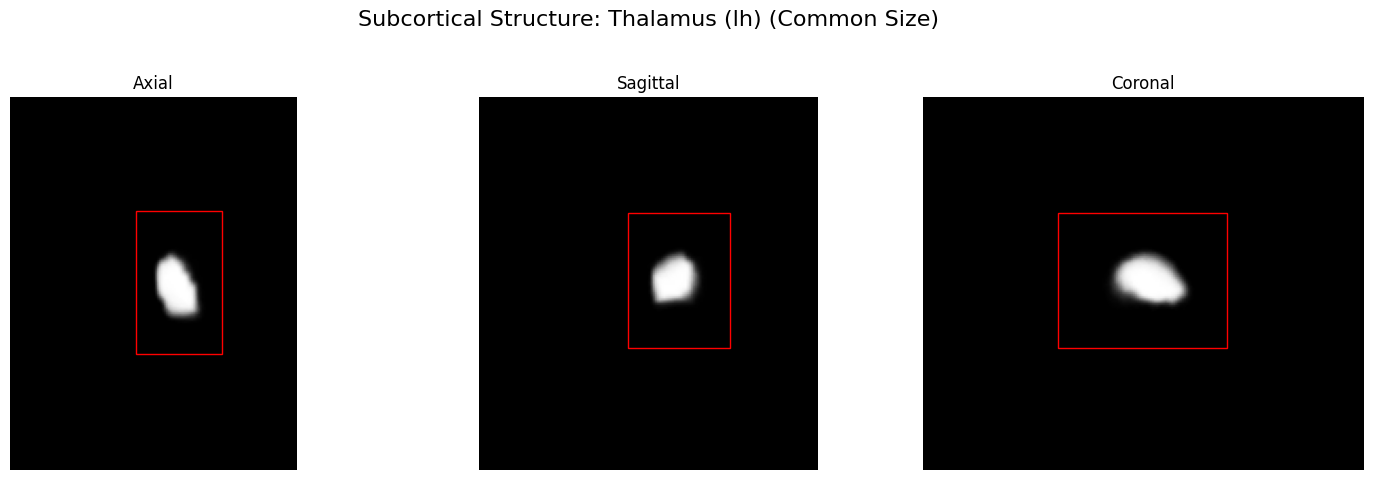

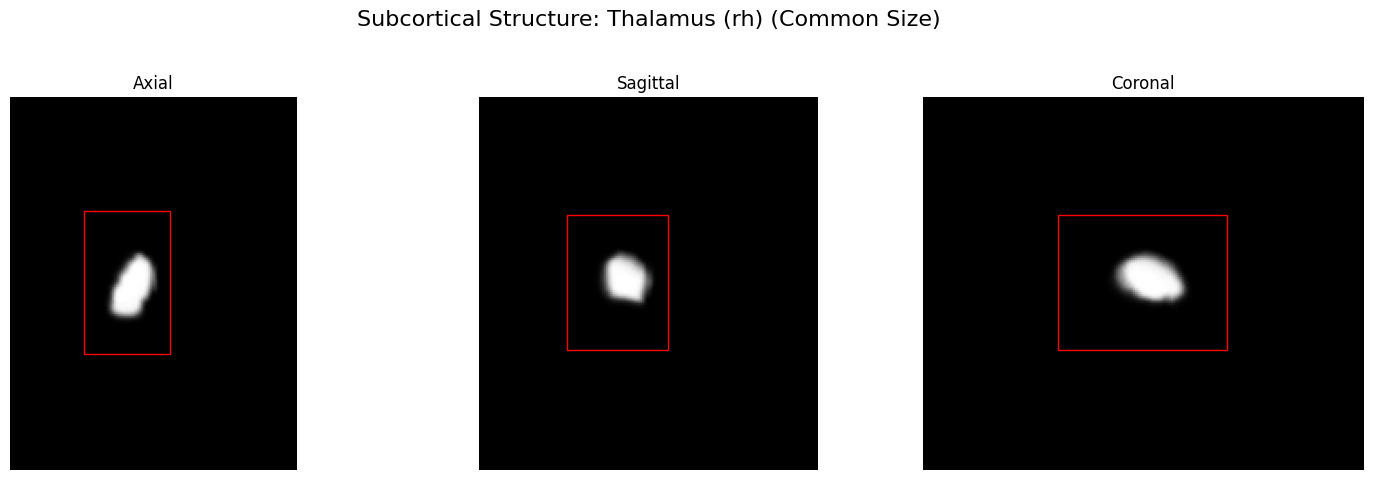

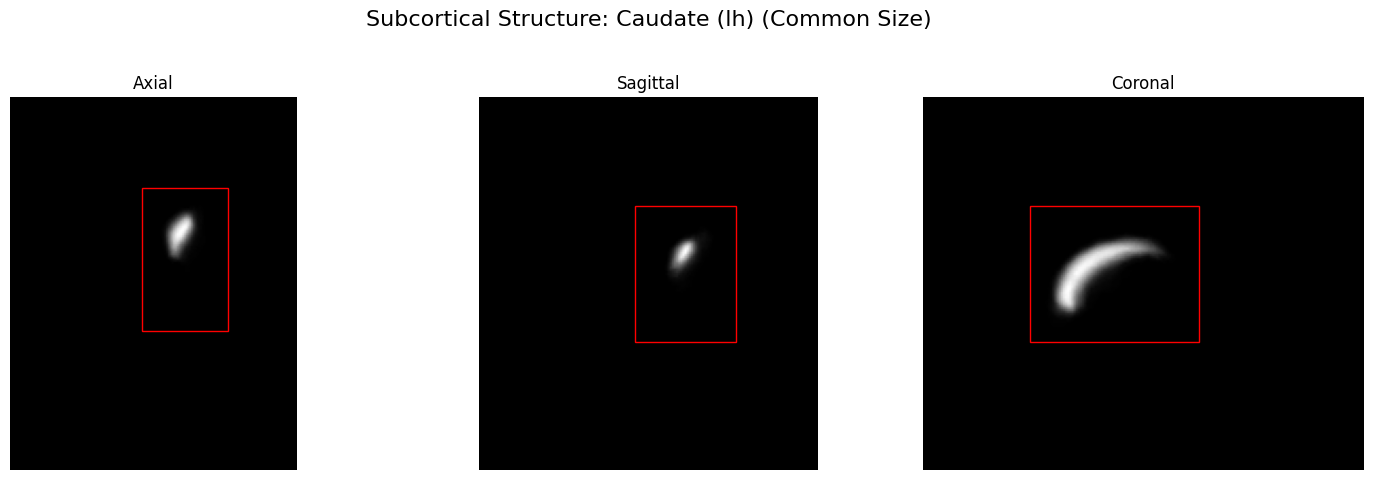

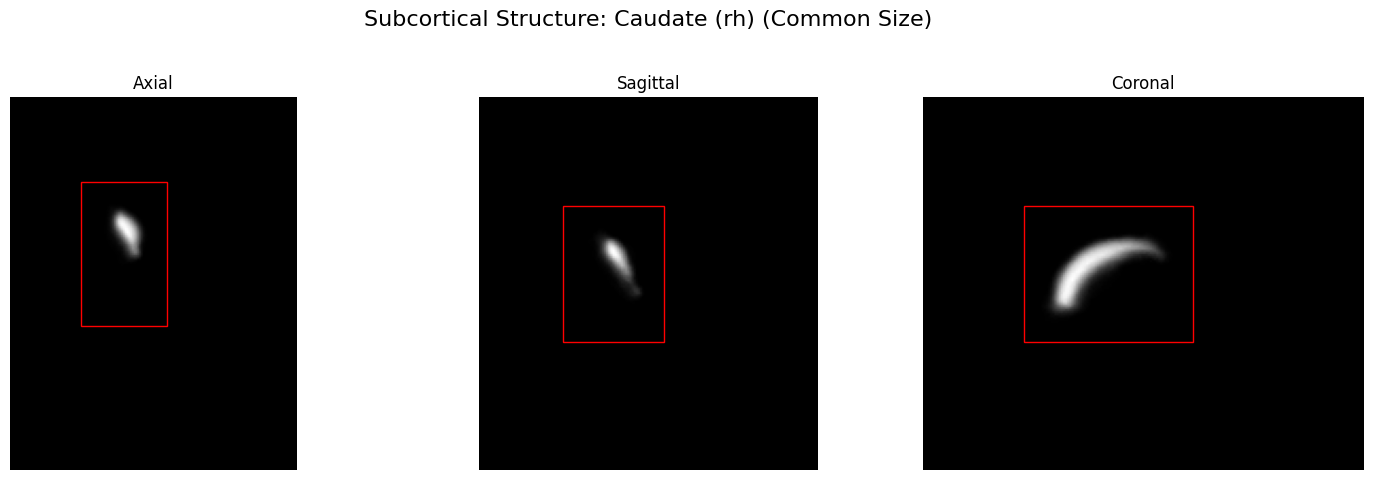

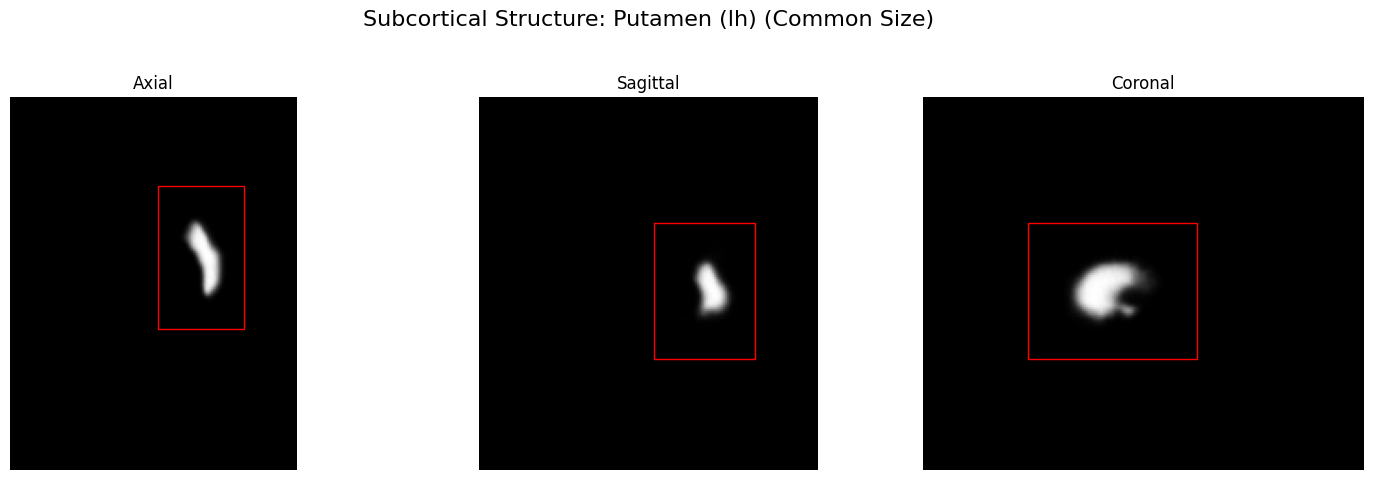

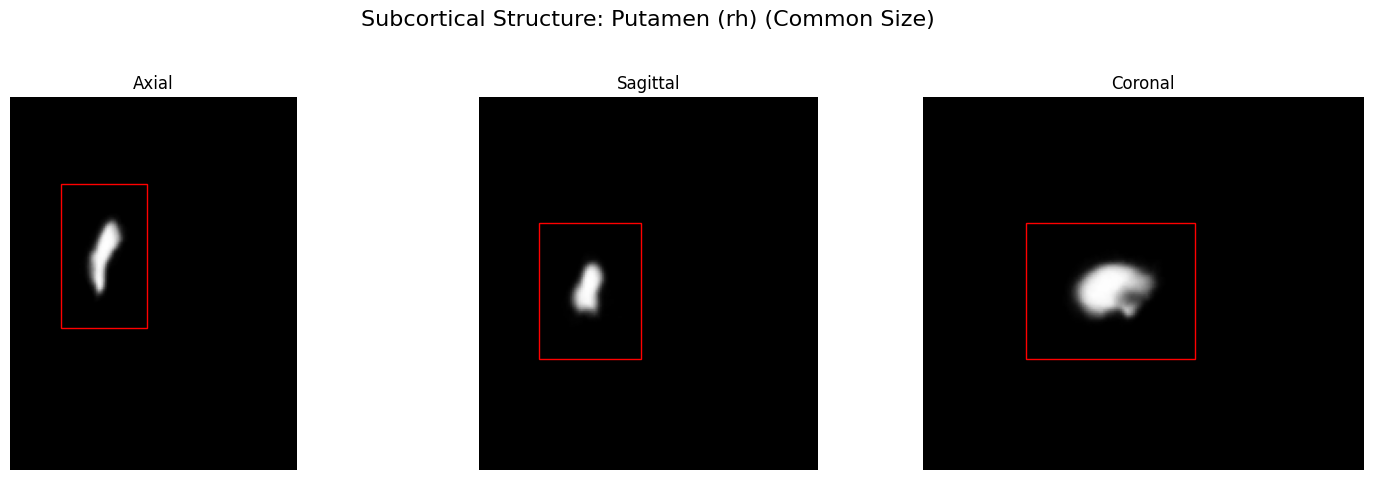

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def extract_bounding_box(segmentation_mask):
    nonzero_indices = np.where(segmentation_mask != 0)
    if nonzero_indices[0].size == 0:
        return None
    min_coords = (int(np.min(nonzero_indices[0])), int(np.min(nonzero_indices[1])), int(np.min(nonzero_indices[2])))
    max_coords = (int(np.max(nonzero_indices[0])), int(np.max(nonzero_indices[1])), int(np.max(nonzero_indices[2])))
    return min_coords, max_coords

all_bounding_boxes = {}
all_combined_seg = {}
for key, value in dementia_subcortical_indices.items():
    combined_seg = np.zeros_like(train_dataset[0]['seg'].squeeze().cpu().numpy(), dtype=np.uint16)
    for i in range(len(train_dataset)):
        print(f"Loading {key} {i+1}/{len(train_dataset)} {(i+1)/len(train_dataset)*100:.1f}% ...", end='\r')
        segmentation_mask = (train_dataset[i]['seg'].squeeze().cpu().numpy() == value).astype(np.uint16)
        combined_seg += segmentation_mask

    print(f"\nProcessing {key} to extract bounding box...")
    bounding_box = extract_bounding_box(combined_seg)
    all_bounding_boxes[key] = bounding_box
    all_combined_seg[key] = combined_seg

print("\nExtracted Bounding Boxes (Initial):")
for key, bbox in all_bounding_boxes.items():
    print(f"{key}: {bbox}")

# Find the maximum extent in each direction across all bounding boxes
max_extent = np.array([0, 0, 0])
for bbox in all_bounding_boxes.values():
    if bbox:
        min_coords, max_coords = bbox
        extent = np.array(max_coords) - np.array(min_coords)
        max_extent = np.maximum(max_extent, extent)

# Add a margin of 2 voxels in each direction to the maximum extent
initial_common_dimension = max_extent + 2 * 2

# Ensure common_dimension is at least 4 times divisible by 2
common_dimension = np.ceil(initial_common_dimension / (2**4)) * (2**4)
common_dimension = common_dimension.astype(int)

print("Initial Common Dimension:", initial_common_dimension)
print("Common Dimension (at least 4 times divisible by 2):", common_dimension)

# Plotting with the common bounding box size and original locations
for key, value in dementia_subcortical_indices.items():
    combined_seg = all_combined_seg[key]
    original_bbox = all_bounding_boxes[key]

    if original_bbox:
        min_coords_orig, max_coords_orig = original_bbox
        center_orig = np.array([(min_coords_orig[i] + max_coords_orig[i]) // 2 for i in range(3)])
        half_common_dim = common_dimension // 2
        min_coords_common = np.maximum(0, center_orig - half_common_dim)
        max_coords_common = min_coords_common + common_dimension
        max_coords_common = np.minimum(combined_seg.shape, max_coords_common)

        min_z, min_y, min_x = min_coords_common
        max_z, max_y, max_x = max_coords_common

        mid_z_orig = (min_coords_orig[0] + max_coords_orig[0]) // 2
        mid_y_orig = (min_coords_orig[1] + max_coords_orig[1]) // 2
        mid_x_orig = (min_coords_orig[2] + max_coords_orig[2]) // 2

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"Subcortical Structure: {key} (Common Size)", fontsize=16)

        axes[0].imshow(combined_seg[mid_z_orig, :, :], cmap="gray")
        axes[0].set_title("Axial")
        axes[0].axis("off")
        rect_xy = (min_x, min_y)
        rect_width = max_x - min_x
        rect_height = max_y - min_y
        rect = plt.Rectangle(rect_xy, rect_width, rect_height, linewidth=1, edgecolor='r', facecolor='none')
        axes[0].add_patch(rect)

        axes[1].imshow(combined_seg[:, mid_y_orig, :], cmap="gray")
        axes[1].set_title("Sagittal")
        axes[1].axis("off")
        rect_xy = (min_x, min_z)
        rect_width = max_x - min_x
        rect_height = max_z - min_z
        rect = plt.Rectangle(rect_xy, rect_width, rect_height, linewidth=1, edgecolor='r', facecolor='none')
        axes[1].add_patch(rect)

        axes[2].imshow(combined_seg[:, :, mid_x_orig], cmap="gray")
        axes[2].set_title("Coronal")
        axes[2].axis("off")
        rect_xy = (min_y, min_z)
        rect_width = max_y - min_y
        rect_height = max_z - min_z
        rect = plt.Rectangle(rect_xy, rect_width, rect_height, linewidth=1, edgecolor='r', facecolor='none')
        axes[2].add_patch(rect)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f"{key}: No segmentation found, cannot plot common size bounding box.")

In [24]:
from preprocessing.segmentation import get_common_bounding_box

common_bounding_boxes = {}
for key, value in dementia_subcortical_indices.items():
    original_bbox = all_bounding_boxes[key]
    common_bounding_boxes[key] = get_common_bounding_box(original_bbox, common_dimension)

In [25]:
common_bounding_boxes

{'Hippocampus (lh)': ((75, 73, 80), (139, 153, 128)),
 'Hippocampus (rh)': ((74, 73, 32), (138, 153, 80)),
 'Amygdala (lh)': ((83, 53, 81), (147, 133, 129)),
 'Amygdala (rh)': ((82, 54, 31), (146, 134, 79)),
 'Thalamus (lh)': ((54, 63, 70), (118, 143, 118)),
 'Thalamus (rh)': ((55, 63, 41), (119, 143, 89)),
 'Caudate (lh)': ((51, 50, 73), (115, 130, 121)),
 'Caudate (rh)': ((51, 47, 39), (115, 127, 87)),
 'Putamen (lh)': ((59, 49, 82), (123, 129, 130)),
 'Putamen (rh)': ((59, 48, 28), (123, 128, 76))}

In [26]:

import numpy as np
import json

# Assuming you have the dictionaries 'all_bounding_boxes' and 'common_bounding_boxes'

# Save the individual bounding boxes as JSON
with open('./data/individual_bounding_boxes.json', 'w') as f:
    json.dump(all_bounding_boxes, f, indent=4)  # indent=4 for pretty printing
print("Individual bounding boxes saved to individual_bounding_boxes.json")

# Save the common bounding boxes as JSON
with open('./data/common_bounding_boxes.json', 'w') as f:
    json.dump(common_bounding_boxes, f, indent=4)  # indent=4 for pretty printing
print("Common bounding boxes saved to common_bounding_boxes.json")


Individual bounding boxes saved to individual_bounding_boxes.json
Common bounding boxes saved to common_bounding_boxes.json


In [19]:
type(int(all_bounding_boxes['Hippocampus (lh)'][0][0]))

int

In [20]:
# Loading MRI  paths
# from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# dataset_path = "/home/maia-user/Dataset/OASIS3/"
# file_paths, file_names = list_files_with_extension(dataset_path, extension="align_norm+cropped.nii.gz")

# raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
# raw_image_ids = np.array([file_path.split('/')[1] for file_path in file_paths])  # e.g., "OAS30001"

# file_paths, file_names = list_files_with_extension(dataset_path, extension="align_aseg.nii.gz")
# raw_seg_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])


# # Optional PE
# # pos_en = positionalencoding2d(4, 128, 128).detach().cpu().numpy()
# pos_en = None

# convert_nii_to_npy(raw_image_paths, raw_seg_paths, raw_image_ids, output_dir="/home/maia-user/Dataset/OASIS3_NPY_UINT/")

In [21]:
halt

NameError: name 'halt' is not defined